In [ ]:
pip install pandas numpy


In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from google.colab import files

# Settings
n_rows = 10000
zones = ['Koramangala', 'Whitefield', 'Indiranagar', 'Jayanagar', 'MG Road']
start_date = datetime(2026, 1, 1)

np.random.seed(42)

# Generate Data
data = pd.DataFrame({
    'trip_id': range(1, n_rows + 1),
    'driver_id': np.random.randint(101, 600, n_rows),
    'pickup_time': [start_date + timedelta(minutes=15*i) for i in range(n_rows)],
    'pickup_zone': np.random.choice(zones, n_rows),
    'drop_zone': np.random.choice(zones, n_rows),
    'distance_km': np.random.uniform(2, 25, n_rows).round(2),
    'surge_multiplier': np.random.choice([1.0, 1.2, 1.5, 2.0], n_rows, p=[0.6, 0.2, 0.15, 0.05])
})

# Logic: Fare (Base ₹50 + ₹15/km) * Surge
data['fare'] = ((50 + (data['distance_km'] * 15)) * data['surge_multiplier']).round(0)
data['drop_time'] = data.apply(lambda row: row['pickup_time'] + timedelta(minutes=int(row['distance_km']*3)), axis=1)

# Save to CSV
data.to_csv('trips.csv', index=False)

print("✅ trips.csv created successfully!")
files.download('trips.csv')

✅ trips.csv created successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

--- FIRST 5 ROWS ---


,trip_id,driver_id,pickup_time,pickup_zone,drop_zone,distance_km,surge_multiplier,fare,drop_time
0,1,203,2026-01-01 00:00:00,Jayanagar,Whitefield,4.08,1.5,167.0,2026-01-01 00:12:00
1,2,536,2026-01-01 00:15:00,Jayanagar,Whitefield,18.09,1.0,321.0,2026-01-01 01:09:00
2,3,449,2026-01-01 00:30:00,Koramangala,Whitefield,18.60,1.0,329.0,2026-01-01 01:25:00
3,4,371,2026-01-01 00:45:00,MG Road,Jayanagar,5.97,1.0,140.0,2026-01-01 01:02:00
4,5,207,2026-01-01 01:00:00,MG Road,Whitefield,2.65,1.0,90.0,2026-01-01 01:07:00



--- DATA SUMMARY ---
Total Trips: 10000
Total Revenue: ₹2,937,114.00
Avg Distance: 13.50 km
Avg Fare: ₹293.71

--- TOP PICKUP ZONES ---


<Axes: title={'center': 'Trips per Zone'}, xlabel='pickup_zone'>

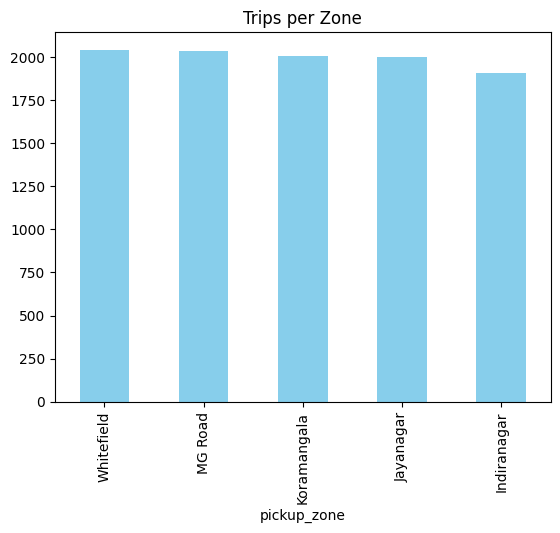

In [ ]:
# 1. Preview the first 5 rows
print("--- FIRST 5 ROWS ---")
display(data.head())

# 2. Check Business Metrics
print("\n--- DATA SUMMARY ---")
summary = {
    "Total Trips": len(data),
    "Total Revenue": f"₹{data['fare'].sum():,.2f}",
    "Avg Distance": f"{data['distance_km'].mean():.2f} km",
    "Avg Fare": f"₹{data['fare'].mean():.2f}"
}
for k, v in summary.items():
    print(f"{k}: {v}")

# 3. Trips by Zone (Quick Bar Chart)
print("\n--- TOP PICKUP ZONES ---")
data['pickup_zone'].value_counts().plot(kind='bar', color='skyblue', title='Trips per Zone')

In [ ]:
import pandas as pd
import sqlite3

# 1. Load the data from the CSV file
df = pd.read_csv('trips.csv')

# 2. Setup the SQL connection and push the data
conn = sqlite3.connect('trips_analysis.db')
df.to_sql('trips', conn, if_exists='replace', index=False)

# 3. Define the helper function (Required for every session)
def run(query):
    return pd.read_sql_query(query, conn)

# 4. SQL Query: Calculate Earnings and Activity per Driver
query_driver_performance = """
SELECT
    driver_id,
    COUNT(trip_id) AS total_trips,
    SUM(fare) AS total_earnings,
    ROUND(AVG(fare), 2) AS avg_earning_per_trip,
    ROUND(AVG(distance_km), 2) AS avg_distance
FROM trips
GROUP BY driver_id
ORDER BY total_earnings DESC
LIMIT 10;
"""

# Execute and Show
driver_stats = run(query_driver_performance)
print("--- TOP 10 DRIVERS BY REVENUE ---")
display(driver_stats)

--- TOP 10 DRIVERS BY REVENUE ---


,driver_id,total_trips,total_earnings,avg_earning_per_trip,avg_distance
0,314,32,11032.0,344.75,16.66
1,254,34,10628.0,312.59,15.36
2,139,31,10560.0,340.65,14.95
3,373,32,10141.0,316.91,14.46
4,413,32,9745.0,304.53,14.38
5,487,29,9342.0,322.14,15.28
6,273,29,9297.0,320.59,16.03
7,125,32,9215.0,287.97,14.68
8,388,29,9211.0,317.62,13.16
9,505,29,9147.0,315.41,13.08


In [ ]:
# Now you can run any SQL query like this:
run("SELECT * FROM trips LIMIT 5")

,trip_id,driver_id,pickup_time,pickup_zone,drop_zone,distance_km,surge_multiplier,fare,drop_time
0,1,203,2026-01-01 00:00:00,Jayanagar,Whitefield,4.08,1.5,167.0,2026-01-01 00:12:00
1,2,536,2026-01-01 00:15:00,Jayanagar,Whitefield,18.09,1.0,321.0,2026-01-01 01:09:00
2,3,449,2026-01-01 00:30:00,Koramangala,Whitefield,18.60,1.0,329.0,2026-01-01 01:25:00
3,4,371,2026-01-01 00:45:00,MG Road,Jayanagar,5.97,1.0,140.0,2026-01-01 01:02:00
4,5,207,2026-01-01 01:00:00,MG Road,Whitefield,2.65,1.0,90.0,2026-01-01 01:07:00


--- TRIP DISTRIBUTION BY HOUR ---


,trip_hour,total_trips,hourly_revenue
0,00,420,119712.0
1,01,420,123513.0
2,02,420,124755.0
3,03,420,129541.0
4,04,416,125649.0
5,05,416,118783.0
6,06,416,116883.0
7,07,416,121820.0
8,08,416,123888.0
9,09,416,120913.0


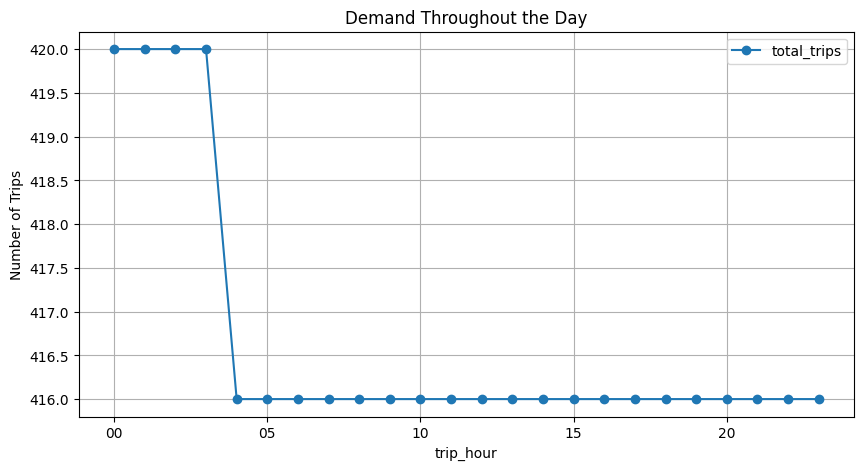

In [ ]:
# Task: Find the busiest hours of the day
# We extract the 'Hour' from the pickup_time to see when demand is highest.

query_peak_hours = """
SELECT
    strftime('%H', pickup_time) AS trip_hour,
    COUNT(trip_id) AS total_trips,
    ROUND(SUM(fare), 2) AS hourly_revenue
FROM trips
GROUP BY trip_hour
ORDER BY trip_hour ASC;
"""

# Run the query
peak_hours_df = run(query_peak_hours)

# Display the data
print("--- TRIP DISTRIBUTION BY HOUR ---")
display(peak_hours_df)

# Optional: Quick visualization to see the trend
import matplotlib.pyplot as plt

peak_hours_df.plot(x='trip_hour', y='total_trips', kind='line', marker='o',
                  title='Demand Throughout the Day', figsize=(10, 5))
plt.ylabel('Number of Trips')
plt.grid(True)
plt.show()

In [ ]:
# Task: Find the top 10 most frequent routes (Pickup -> Dropoff)
query_routes = """
SELECT
    pickup_zone,
    drop_zone,
    COUNT(trip_id) AS trip_count,
    ROUND(AVG(fare), 2) AS avg_fare,
    ROUND(SUM(fare), 2) AS total_revenue
FROM trips
GROUP BY pickup_zone, drop_zone
ORDER BY trip_count DESC
LIMIT 10;
"""

# Execute the query
route_performance = run(query_routes)

# Display the data
print("--- TOP 10 MOST POPULAR ROUTES ---")
display(route_performance)

# Optional: Create a Pivot Table to see the flow between zones
print("\n--- ZONE FLOW MATRIX (Trip Counts) ---")
route_pivot = run("SELECT pickup_zone, drop_zone, COUNT(*) as count FROM trips GROUP BY 1, 2")
matrix = route_pivot.pivot(index='pickup_zone', columns='drop_zone', values='count')
display(matrix)

--- TOP 10 MOST POPULAR ROUTES ---


,pickup_zone,drop_zone,trip_count,avg_fare,total_revenue
0,Whitefield,MG Road,438,297.66,130377.0
1,MG Road,Jayanagar,435,290.77,126487.0
2,Whitefield,Indiranagar,427,294.44,125727.0
3,Jayanagar,Jayanagar,421,294.12,123824.0
4,Koramangala,Koramangala,418,301.59,126065.0
5,Jayanagar,Whitefield,416,295.51,122932.0
6,MG Road,Whitefield,410,291.37,119463.0
7,Koramangala,Whitefield,409,298.48,122077.0
8,Indiranagar,Jayanagar,407,274.63,111773.0
9,Jayanagar,Koramangala,406,294.06,119388.0



--- ZONE FLOW MATRIX (Trip Counts) ---


drop_zone,Indiranagar,Jayanagar,Koramangala,MG Road,Whitefield
pickup_zone,,,,,
Indiranagar,369,407,351,383,399
Jayanagar,375,421,406,386,416
Koramangala,403,391,418,384,409
MG Road,396,435,393,403,410
Whitefield,427,387,406,438,387


--- SURGE PRICING IMPACT ---


,surge_multiplier,total_trips,total_revenue,revenue_at_base_rate,surge_profit_increment
0,1.0,6050,1529202.0,1529202.00,0.00
1,1.2,1956,593818.0,494848.33,98969.67
2,1.5,1495,565710.0,377140.00,188570.00
3,2.0,499,248384.0,124192.00,124192.00



💰 Total additional revenue generated by Surge Pricing: ₹411,731.67


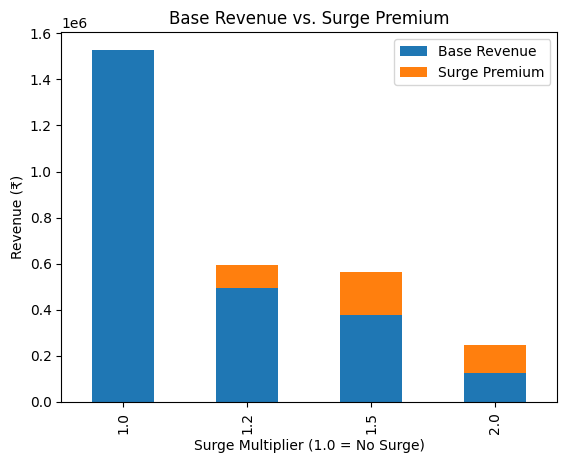

In [ ]:
# Task: Analyze the impact of Surge Pricing on Revenue
# We calculate how much "Extra" money was made specifically because of the surge multipliers.

query_surge = """
SELECT
    surge_multiplier,
    COUNT(trip_id) AS total_trips,
    ROUND(SUM(fare), 2) AS total_revenue,
    ROUND(SUM(fare / surge_multiplier), 2) AS revenue_at_base_rate,
    ROUND(SUM(fare - (fare / surge_multiplier)), 2) AS surge_profit_increment
FROM trips
GROUP BY surge_multiplier
ORDER BY surge_multiplier ASC;
"""

# Run the query
surge_analysis = run(query_surge)

# Display the data
print("--- SURGE PRICING IMPACT ---")
display(surge_analysis)

# Calculation: Total Extra Profit from Surge
total_extra = surge_analysis['surge_profit_increment'].sum()
print(f"\n💰 Total additional revenue generated by Surge Pricing: ₹{total_extra:,.2f}")

# Visualization: Surge vs. Base Revenue
import matplotlib.pyplot as plt

surge_analysis.plot(x='surge_multiplier', y=['revenue_at_base_rate', 'surge_profit_increment'],
                    kind='bar', stacked=True, color=['#1f77b4', '#ff7f0e'],
                    title='Base Revenue vs. Surge Premium')
plt.ylabel('Revenue (₹)')
plt.xlabel('Surge Multiplier (1.0 = No Surge)')
plt.legend(["Base Revenue", "Surge Premium"])
plt.show()

In [ ]:
# Task 1: Driver Efficiency (Who makes the most money with the least driving?)
# Task 2: Route Profitability (Which specific 'Pickup to Dropoff' path has the highest avg fare?)

query_advanced = """
SELECT
    driver_id,
    SUM(fare) as total_revenue,
    SUM(distance_km) as total_km,
    ROUND(SUM(fare) / SUM(distance_km), 2) as revenue_per_km,
    COUNT(trip_id) as total_trips
FROM trips
GROUP BY driver_id
HAVING total_trips > 5
ORDER BY revenue_per_km DESC
LIMIT 10;
"""

query_route_profit = """
SELECT
    pickup_zone,
    drop_zone,
    ROUND(AVG(fare), 2) as avg_fare,
    ROUND(AVG(surge_multiplier), 2) as avg_surge,
    COUNT(*) as trip_count
FROM trips
GROUP BY pickup_zone, drop_zone
ORDER BY avg_fare DESC
LIMIT 10;
"""

# Execute and Show Efficiency
driver_efficiency = run(query_advanced)
print("--- TOP 10 EFFICIENT DRIVERS (Revenue per KM) ---")
display(driver_efficiency)

# Execute and Show Route Profits
route_profit = run(query_route_profit)
print("\n--- TOP 10 MOST PROFITABLE ROUTES ---")
display(route_profit)

--- TOP 10 EFFICIENT DRIVERS (Revenue per KM) ---


,driver_id,total_revenue,total_km,revenue_per_km,total_trips
0,109,5658.0,214.42,26.39,16
1,271,5900.0,224.56,26.27,21
2,498,4821.0,184.91,26.07,15
3,316,6657.0,256.23,25.98,24
4,267,5253.0,203.66,25.79,15
5,346,8032.0,312.84,25.67,27
6,238,6110.0,240.04,25.45,19
7,483,6423.0,253.19,25.37,20
8,433,4454.0,175.85,25.33,15
9,311,5467.0,216.22,25.28,15



--- TOP 10 MOST PROFITABLE ROUTES ---


,pickup_zone,drop_zone,avg_fare,avg_surge,trip_count
0,Whitefield,Whitefield,303.21,1.19,387
1,Indiranagar,Koramangala,302.04,1.18,351
2,Koramangala,Koramangala,301.59,1.17,418
3,Jayanagar,Indiranagar,299.49,1.18,375
4,Jayanagar,MG Road,298.90,1.17,386
5,Koramangala,Whitefield,298.48,1.18,409
6,Whitefield,Koramangala,297.74,1.16,406
7,Whitefield,MG Road,297.66,1.16,438
8,Koramangala,MG Road,296.90,1.17,384
9,Jayanagar,Whitefield,295.51,1.17,416


In [ ]:
# STEP 6: THE MASTER EXPORT (Preparing the "Standout" Dataset for Power BI)
# We are creating a "Star Schema" structure: 1 Fact Table and 3 Dimension Tables.
# This is how professional Data Engineers prepare data for Power BI.

import pandas as pd
import sqlite3
from google.colab import files

conn = sqlite3.connect('trips_analysis.db')

def run(query):
    return pd.read_sql_query(query, conn)

print("🛠️ Generating Master Export files...")

# 1. FACT TABLE: The main trip records with calculated time features
# We extract Hour, Day of Week, and Month for time-series analysis in Power BI
fact_trips = run("""
    SELECT
        trip_id,
        driver_id,
        pickup_time,
        pickup_zone,
        drop_zone,
        distance_km,
        surge_multiplier,
        fare,
        strftime('%H', pickup_time) as pickup_hour,
        strftime('%w', pickup_time) as day_of_week,
        strftime('%m', pickup_time) as month
    FROM trips
""")
fact_trips.to_csv('fact_trips.csv', index=False)

# 2. DIM_DRIVERS: Driver Performance metrics (Advanced)
dim_drivers = run("""
    SELECT
        driver_id,
        COUNT(*) as lifetime_trips,
        SUM(fare) as total_earnings,
        ROUND(SUM(fare) / SUM(distance_km), 2) as revenue_per_km,
        ROUND(AVG(surge_multiplier), 2) as avg_surge_accepted
    FROM trips
    GROUP BY driver_id
""")
dim_drivers.to_csv('dim_drivers.csv', index=False)

# 3. DIM_ZONES: Zone-based metrics for Map Visuals
dim_zones = run("""
    SELECT
        pickup_zone as zone_name,
        COUNT(*) as demand_count,
        SUM(fare) as total_revenue,
        ROUND(AVG(fare), 2) as avg_ticket_size
    FROM trips
    GROUP BY pickup_zone
""")
dim_zones.to_csv('dim_zones.csv', index=False)

# 4. DIM_ROUTES: Popularity and profitability of specific paths
dim_routes = run("""
    SELECT
        pickup_zone || ' to ' || drop_zone as route_path,
        COUNT(*) as trip_frequency,
        ROUND(AVG(fare), 2) as route_avg_fare,
        ROUND(SUM(fare), 2) as route_total_revenue
    FROM trips
    GROUP BY route_path
""")
dim_routes.to_csv('dim_routes.csv', index=False)

# Download all 4 files
for file in ['fact_trips.csv', 'dim_drivers.csv', 'dim_zones.csv', 'dim_routes.csv']:
    files.download(file)

print("✅ SUCCESS: All 4 Master Files downloaded!")
print("1. fact_trips.csv (The Raw Data)")
print("2. dim_drivers.csv (The Driver Rankings)")
print("3. dim_zones.csv (The Map Data)")
print("4. dim_routes.csv (The Route Profitability)")

🛠️ Generating Master Export files...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ SUCCESS: All 4 Master Files downloaded!
1. fact_trips.csv (The Raw Data)
2. dim_drivers.csv (The Driver Rankings)
3. dim_zones.csv (The Map Data)
4. dim_routes.csv (The Route Profitability)
